In [1]:
# Setup — all imports live here so the notebook executes top-to-bottom
# without reimporting mid-notebook. When running headlessly (CI, HPC),
# uncomment the ``matplotlib.use('Agg')`` line *before* the pyplot import
# so figures never need an interactive display.
import dataclasses
import logging
import os
import sys
from collections import Counter
from pathlib import Path

# import matplotlib
# matplotlib.use('Agg')  # enable for headless runs
import matplotlib.pyplot as plt
import mne
import numpy as np
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from mne.viz import plot_topomap
from scipy.sparse.csgraph import connected_components
from scipy.stats import pearsonr

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:  # noqa: B007
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from independent_vector_analysis import iva_g  # noqa: E402
from sklearn.decomposition import PCA  # noqa: E402

from scripts.analysis_common import (  # noqa: E402
    FREQUENCY_BANDS,
    WAVELET_BAND_FREQ_RESOLUTION_HZ,
    analyzers_to_datasets,
    load_analyzers,
    wavelet_transform,
)
from src.analysis.wavelet_ica import zscore_by_time  # noqa: E402
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
%matplotlib inline

# IVA Decomposition of Wavelet Power — (Subject × Channel) Datasets

## Scope

Variant of `wavelet_iva_subjects.ipynb` where the **datasets passed to
IVA are individual `(subject, channel)` pairs** rather than whole
subjects. Concretely IVA sees `K = S × C` datasets, each of which is
a single channel of a single subject, with **frequency** as the
feature axis and **time** as the sample axis:

```
Input:   (n_subjects, n_channels, n_freqs, n_times)
Reshape: (n_subjects * n_channels,  n_freqs, n_times)
              ── datasets ──        ─ N ─    ─ T ─
Stack:   (n_freqs, n_times, n_subjects * n_channels)  — IVA layout (N, T, K)
```

Two consequences:

1. Components live in a **frequency-only** feature space — they
   describe spectro-temporal modes that should look similar across
   *any* `(subject, channel)` view. The spatial information is now
   carried by the K-axis instead of the feature axis.
2. `n_freqs` is small (≈ 70 with the default 1 Hz resolution), so a
   per-dataset PCA reduction is **not strictly needed**; it can be
   enabled via `USE_PCA` for very large feature dimensions but is
   skipped by default.

Like the subjects-as-datasets notebook, IVA aligns the kth source
across all datasets by construction — but here "across datasets" means
across **every `(subject, channel)` pair**, not just across subjects.

## Pipeline

1. Load broadband wavelet power for the chosen condition / music type.
2. Apply subject / channel / time subsets.
3. Z-score along time.
4. Flatten the `(S, C)` axes into a single dataset axis, producing
   `(S × C, F, T)`.
5. Optionally reduce features via per-dataset PCA (off by default).
6. Stack into `(F, T, S × C)` and run **IVA-G**.
7. Recover per-dataset sources and per-dataset component patterns in
   the original frequency space; reshape K → `(S, C)`.

After the final cell the following variables are available:

| Variable | Shape | Description |
|----------|-------|-------------|
| `bb_data` | `(S, C, F, T)` | Raw 4-D wavelet power tensor |
| `bb_z` | `(S, C, F, T)` | Z-scored wavelet power tensor |
| `X_datasets` | `(S × C, F, T)` | Per-`(s,c)` z-scored stack |
| `X_iva` | `(N_IVA, T, S × C)` | IVA input layout |
| `W` | `(N_IVA, N_IVA, S × C)` | Per-`(s,c)` IVA demixing matrices |
| `iva_sources` | `(S, C, N_IVA, T)` | Sources reshaped back to `(s, c, …)` |
| `iva_components` | `(S, C, N_IVA, F)` | Frequency patterns reshaped to `(s, c, …)` |

## Configuration

In [2]:
# ── Experiment configuration ───────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL]  # single type for fast exploration
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]
PROCESS_AND_SAVE_DATA = False  # set True to re-process raw files

# ── Wavelet settings ─────────────────────────────────────────
REPRESENTATION = "power"
WAVELET_FREQ_MIN = min(lo for lo, _ in FREQUENCY_BANDS.values())
WAVELET_FREQ_MAX = max(hi for _, hi in FREQUENCY_BANDS.values())
WAVELET_N_FREQS = max(
    2,
    int(round((WAVELET_FREQ_MAX - WAVELET_FREQ_MIN) / WAVELET_BAND_FREQ_RESOLUTION_HZ))
    + 1,
)
FREQS = np.linspace(WAVELET_FREQ_MIN, WAVELET_FREQ_MAX, WAVELET_N_FREQS)

KEEP_FREQUENCY_DIM = True
RESHAPE_FREQUENCY_DIM = True  # -> (n_subjects, n_channels, n_freqs, n_times)

# ── Reuse / compute ──────────────────────────────────────────
REUSE_WAVELETS = True  # load from cache; set False to compute + save

# ── Subject subset ────────────────────────────────────────────
N_SUBJECTS_SUBSET: int | None = 5

# ── Channel and time subset ─────────────────────────────────────
N_CHANNELS_SUBSET: int | None = 32  # first N channels (from 195)
N_TIMES_SUBSET: int | None = 10000  # first N time samples

# ── IVA settings ──────────────────────────────────────────────
# Per-(s,c) feature dim is F (~70 with 1 Hz resolution), which IVA-G
# can usually whiten directly. Enable USE_PCA only if F is very large.
USE_PCA = False
N_COMPONENTS_PCA = 30  # per-dataset PCA dim when USE_PCA is True
IVA_OPT_APPROACH = "newton"  # 'gradient', 'newton', or 'quasi'
IVA_MAX_ITER = 1024
IVA_W_DIFF_STOP = 1e-6
IVA_VERBOSE = True
IVA_RANDOM_STATE = 42  # seeds per-dataset PCA + W_init

# ── Storage directory ─────────────────────────────────────────
WAVELET_DIR: Path = (
    ProjectPaths.NOTEBOOKS_DIR / "04-wavelet-ica-analysis" / "wavelet_cache"
)

# ── Downstream analysis settings ──────────────────────────────
N_COMPONENTS_SHOW = 10  # number of IVA components to visualise downstream
SAVE_PLOTS = True
PLOTS_DIR = (
    ProjectPaths.NOTEBOOKS_DIR
    / "05-wavelet-iva-analysis"
    / "plots"
    / "broadband"
    / "iva_subject_channel"
)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Wavelet base directory : {WAVELET_DIR}")
print(f"Plots directory        : {PLOTS_DIR}")
print(
    f"Frequencies            : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({len(FREQS)} steps)"
)
print(f"Use PCA per (s,c)      : {USE_PCA}  (target dim = {N_COMPONENTS_PCA})")
print(f"IVA optimisation       : {IVA_OPT_APPROACH}")
print(f"Components to show     : {N_COMPONENTS_SHOW}")

Wavelet base directory : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache
Plots directory        : /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/05-wavelet-iva-analysis/plots/broadband/iva_subject_channel
Frequencies            : 1.0–70.0 Hz (70 steps)
Use PCA per (s,c)      : False  (target dim = 30)
IVA optimisation       : newton
Components to show     : 10


## Data Loading

In [3]:
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    PROCESS_AND_SAVE_DATA,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)

# Always limit to first N_SUBJECTS_SUBSET individuals
if N_SUBJECTS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:N_SUBJECTS_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_SUBJECTS_SUBSET} individuals.")

# Slice to channel subset
if N_CHANNELS_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :N_CHANNELS_SUBSET, :])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_CHANNELS_SUBSET} channels.")

# Slice to time subset
if N_TIMES_SUBSET is not None:
    datasets = {
        label: dataclasses.replace(ad, data=ad.data[:, :, :N_TIMES_SUBSET])
        for label, ad in datasets.items()
    }
    print(f"Using first {N_TIMES_SUBSET} time samples.")

print("Loaded datasets:", list(datasets.keys()))
for label, ad in datasets.items():
    print(
        f"  {label}: {ad.n_items} subjects, {ad.n_features} channels, "
        f"{ad.n_samples} samples"
    )

INFO src.analysis.summary.EEGSummarizedAnalyzer: Data loaded from /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/concatenated/Placebo_CLASSIC.npy  (shape=(15, 195, 91392))


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(
INFO scripts.analysis_common: [Placebo_CLASSIC] Loaded data shape: (15, 195, 91392)
INFO scripts.analysis_common: [Placebo_CLASSIC] AnalysisData('Placebo_CLASSIC', time_domain, 15 items × 195 features × 91392 samples, sfreq=250.0)


Using first 5 individuals.
Using first 32 channels.
Using first 10000 time samples.
Loaded datasets: ['Placebo_CLASSIC']
  Placebo_CLASSIC: 5 subjects, 32 channels, 10000 samples


## Load or Compute Wavelet Transforms

Stored in `WAVELET_DIR/broadband/` (shared with the 04 ICA notebooks).

In [4]:
broadband_datasets = wavelet_transform(
    datasets=datasets,
    freqs=FREQS,
    representation=REPRESENTATION,
    keep_frequency_dim=KEEP_FREQUENCY_DIM,
    reshape_frequency_dim=RESHAPE_FREQUENCY_DIM,
    wavelet_dir=WAVELET_DIR / "broadband",
    reuse_wavelets=REUSE_WAVELETS,
)
for label, ad in broadband_datasets.items():
    source = ad.metadata.get("loaded_from_wavelet_file", "computed_now")
    print(f"[broadband] {label}: shape={ad.data.shape}  source={source}")

[broadband] Placebo_CLASSIC: shape=(5, 32, 70, 10000)  source=/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/04-wavelet-ica-analysis/wavelet_cache/broadband/Placebo_CLASSIC__wavelet_power__1.000_70.000_70__freqdim1.npz


## Dataset Selection

Change `LABEL` to switch between music types. The remaining cells use
`bb_data` (broadband wavelet power, 4-D) and derived quantities.

In [5]:
LABEL = list(broadband_datasets.keys())[0]

bb_ad = broadband_datasets[LABEL]
bb_data = bb_ad.data  # (n_subjects, n_channels, n_freqs, n_times)
sfreq = bb_ad.sfreq

n_subjects, n_channels, n_freqs, n_times = bb_data.shape
time = np.arange(n_times) / sfreq

print(f"Dataset    : {LABEL}")
print(f"Shape      : {bb_data.shape}  (subjects × channels × freqs × times)")
print(f"Duration   : {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print(f"Freq range : {FREQS[0]:.1f}–{FREQS[-1]:.1f} Hz ({n_freqs} steps)")

Dataset    : Placebo_CLASSIC
Shape      : (5, 32, 70, 10000)  (subjects × channels × freqs × times)
Duration   : 40.0 s  @  250.0 Hz
Freq range : 1.0–70.0 Hz (70 steps)


---
## Step 1 — Z-score and `(S × C)` Reshape

**Z-scoring** normalises each `(subject, channel, frequency)` time
series to zero mean and unit variance.

**Reshape** flattens the `(S, C)` axes into a single dataset axis:
each `(subject, channel)` pair becomes one IVA dataset whose features
are the `F` frequencies and whose samples are the `T` time points.

```
(S, C, F, T)  →  reshape  →  (S × C, F, T)
                             datasets  N=F  T=T
```

| Quantity | Shape | Description |
|----------|-------|-------------|
| `bb_z` | `(S, C, F, T)` | Z-scored wavelet power |
| `X_datasets` | `(S × C, F, T)` | Per-`(s,c)` z-scored stack |
| `n_datasets` | `int` | `S × C`, the number of IVA datasets |

In [6]:
# Z-score along time: each (subject, channel, frequency) slice → mean=0, std=1
bb_z = zscore_by_time(bb_data)  # (S, C, F, T)

# Flatten (S, C) into a single dataset axis.
n_datasets = n_subjects * n_channels
X_datasets = bb_z.reshape(n_datasets, n_freqs, n_times)  # (S*C, F, T)

print(f"Per-(s,c) reshape      : {X_datasets.shape}  ((S*C), F, T)")
print(f"  Datasets             : {n_datasets} = S({n_subjects}) * C({n_channels})")
print(f"  Features per dataset : {n_freqs}")
print(f"  Samples per dataset  : {n_times}")

Per-(s,c) reshape      : (160, 70, 10000)  ((S*C), F, T)
  Datasets             : 160 = S(5) * C(32)
  Features per dataset : 70
  Samples per dataset  : 10000


---
## Step 2 — Build IVA Input

The IVA layout is `(N, T, K)`. We stack the per-`(s,c)` matrices so
that:

```
X_datasets    : (S × C, F, T)   ← Python view from the reshape above
X_iva         : (N_IVA, T, S × C)   ← IVA input (transpose)
```

**Optional per-dataset PCA**: when `USE_PCA = True`, each `(s, c)`
matrix is reduced from `F` features down to `N_COMPONENTS_PCA`
components before stacking. With the default
`WAVELET_BAND_FREQ_RESOLUTION_HZ = 1.0` the broadband range gives
`F ≈ 70`, which IVA-G can usually handle directly, so PCA is skipped
by default and `N_IVA = F`.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `pcas[d]` | — | Per-dataset PCA object (only when `USE_PCA`) |
| `pca_evr` | `(S × C, N_IVA)` | Per-dataset explained-variance ratio |
| `X_iva` | `(N_IVA, T, S × C)` | IVA input |
| `N_IVA` | `int` | `N_COMPONENTS_PCA` (if PCA) or `n_freqs` |

In [7]:
pcas: list[PCA] = []

if USE_PCA:
    pca_scores = np.zeros((n_datasets, N_COMPONENTS_PCA, n_times))
    pca_evr = np.zeros((n_datasets, N_COMPONENTS_PCA))
    for d in range(n_datasets):
        mat = X_datasets[d].T  # (T, F) — sklearn expects samples × features
        pca = PCA(n_components=N_COMPONENTS_PCA, random_state=IVA_RANDOM_STATE)
        scores = pca.fit_transform(mat)  # (T, N_PCA)
        pcas.append(pca)
        pca_scores[d] = scores.T  # (N_PCA, T)
        pca_evr[d] = pca.explained_variance_ratio_
    X_iva = np.ascontiguousarray(pca_scores.transpose(1, 2, 0))  # (N_PCA, T, S*C)
    N_IVA = N_COMPONENTS_PCA
    print(f"Per-dataset PCA applied: F={n_freqs} → N_IVA={N_IVA}")
    print(f"Mean retained variance : {pca_evr.sum(axis=1).mean() * 100:.1f}%")
else:
    pca_evr = np.zeros((n_datasets, n_freqs))
    X_iva = np.ascontiguousarray(X_datasets.transpose(1, 2, 0))  # (F, T, S*C)
    N_IVA = n_freqs
    print(f"PCA skipped — using all {n_freqs} frequencies as features.")

print(f"IVA input shape        : {X_iva.shape}  (N={N_IVA}, T, K={n_datasets})")

PCA skipped — using all 70 frequencies as features.
IVA input shape        : (70, 10000, 160)  (N=70, T, K=160)


---
## Step 3 — Run IVA-G

`iva_g` returns `W` of shape `(N, N, K)` with `N = N_IVA` and
`K = S × C`. The kth source for dataset `d = (s, c)` is

```
sources_d[k, :] = W[:, :, d] @ X_iva[:, :, d]    # (N_IVA, T)
```

IVA aligns the kth source across **every** `(s, c)` dataset by
construction.

| Returned by `iva_g` | Shape | Description |
|---------------------|-------|-------------|
| `W` | `(N_IVA, N_IVA, S × C)` | Per-dataset demixing matrix |
| `cost` | `(n_iter,)` | IVA cost per iteration |
| `Sigma_N` | `(K, K, N_IVA)` | Per-SCV covariance across `(s,c)` datasets |
| `isi` | `float` | Joint ISI (only when ground-truth `A` is given) |

Step 0: W change: 0.9999642891400414, Cost: 47028.226165889704
Step 1: W change: 0.16108821896272707, Cost: 13192.232615538267
Step 2: W change: 0.060836459311166324, Cost: 11477.711543002268
IVA-G finished after 22.809122796853384 minutes with 2 iterations.

W shape           : (70, 70, 160)  (N_IVA, N_IVA, K=S*C)
Sigma_N shape     : (160, 160, 70)  (K, K, N_IVA)
Iterations        : 3
Final cost        : 11477.711543


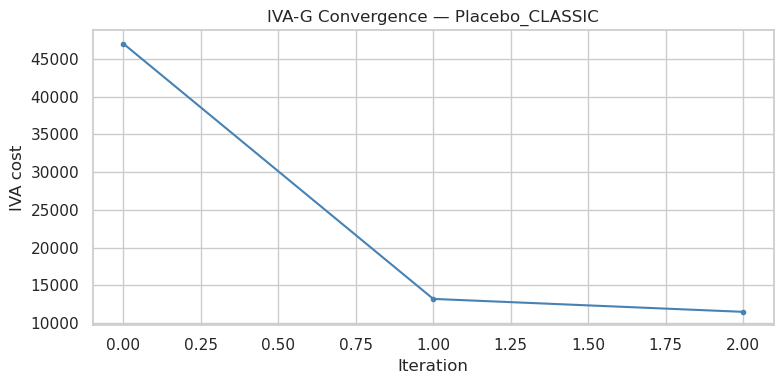

In [10]:
# Deterministic W initialisation: random matrix per dataset seeded by IVA_RANDOM_STATE.
rng = np.random.default_rng(IVA_RANDOM_STATE)
W_init = rng.standard_normal((N_IVA, N_IVA, n_datasets))

W, cost, Sigma_N, isi = iva_g(
    X_iva,
    opt_approach=IVA_OPT_APPROACH,
    whiten=True,
    verbose=IVA_VERBOSE,
    W_init=W_init,
    max_iter=3, #IVA_MAX_ITER,
    W_diff_stop=IVA_W_DIFF_STOP,
)

print(f"\nW shape           : {W.shape}  (N_IVA, N_IVA, K=S*C)")
print(f"Sigma_N shape     : {Sigma_N.shape}  (K, K, N_IVA)")
print(f"Iterations        : {len(cost)}")
print(f"Final cost        : {cost[-1]:.6f}")

# Cost-curve sanity check.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost, marker="o", markersize=3, color="steelblue")
ax.set_xlabel("Iteration")
ax.set_ylabel("IVA cost")
ax.set_title(f"IVA-G Convergence — {LABEL}")
fig.tight_layout()
plt.show()
plt.close("all")

---
## Step 4 — Recover Sources and Component Patterns

For each `(s, c)` dataset, apply the demixing matrix to recover the
sources, and combine `W_d` with the PCA loadings (when PCA is on) to
express each component pattern in the original `F`-dim frequency
space. The flat K-axis is then reshaped back to `(S, C, …)` so
downstream code can index by `(subject, channel)` directly.

| Recovered variable | Shape | Description |
|--------------------|-------|-------------|
| `iva_sources` | `(S, C, N_IVA, T)` | Source timecourses per `(s, c)` |
| `iva_components` | `(S, C, N_IVA, F)` | Frequency-pattern per `(s, c)` |

In [11]:
iva_sources_flat = np.zeros((n_datasets, N_IVA, n_times))
iva_components_flat = np.zeros((n_datasets, N_IVA, n_freqs))

for d in range(n_datasets):
    W_d = W[:, :, d]  # (N_IVA, N_IVA)
    X_d = X_iva[:, :, d]  # (N_IVA, T)
    iva_sources_flat[d] = W_d @ X_d
    if USE_PCA:
        # Project the unmixing rows back through the per-dataset PCA loadings to
        # express the components in the original F-dim feature space.
        iva_components_flat[d] = W_d @ pcas[d].components_  # (N_IVA, F)
    else:
        # No PCA: each row of W_d is already a length-F frequency pattern.
        iva_components_flat[d] = W_d  # (F, F)

# Reshape the flat K-axis back to (S, C, …) for indexing by (subject, channel).
iva_sources = iva_sources_flat.reshape(n_subjects, n_channels, N_IVA, n_times)
iva_components = iva_components_flat.reshape(n_subjects, n_channels, N_IVA, n_freqs)

print(f"IVA sources       : {iva_sources.shape}     (S, C, N_IVA, T)")
print(f"IVA components    : {iva_components.shape}  (S, C, N_IVA, F)")

IVA sources       : (5, 32, 70, 10000)     (S, C, N_IVA, T)
IVA components    : (5, 32, 70, 70)  (S, C, N_IVA, F)


---
## Result Summary

All variables required for downstream analyses are now in memory:

| Variable | Shape | Description |
|----------|-------|-------------|
| `bb_data` | `(S, C, F, T)` | Raw 4-D wavelet power tensor |
| `bb_z` | `(S, C, F, T)` | Z-scored wavelet power tensor |
| `X_datasets` | `(S × C, F, T)` | Per-`(s, c)` z-scored stack |
| `pcas` | list[`PCA`] | Per-dataset fitted PCA objects (empty when `USE_PCA=False`) |
| `pca_evr` | `(S × C, N_IVA)` | Per-dataset PCA explained-variance ratio |
| `X_iva` | `(N_IVA, T, S × C)` | IVA input |
| `W` | `(N_IVA, N_IVA, S × C)` | Per-dataset IVA demixing |
| `Sigma_N` | `(S × C, S × C, N_IVA)` | Per-SCV covariance across `(s, c)` |
| `cost` | `(n_iter,)` | IVA convergence trace |
| `iva_sources` | `(S, C, N_IVA, T)` | Source timecourses per `(s, c)` |
| `iva_components` | `(S, C, N_IVA, F)` | Frequency-pattern per `(s, c)` |

IVA aligns the kth source / component across **every** `(s, c)`
dataset — downstream analyses can sensibly aggregate over the
C-axis to get per-subject views, or over `(S, C)` to get fully
cross-cohort views.

# Downstream Analyses

Each `(subject, channel)` pair is its own IVA dataset, so the natural
per-component summaries collapse the C-axis first:

```
per_subject_source[s, k, :]  = iva_sources[s, :, k, :].mean(axis=0)     # (S, K, T)
per_subject_pattern[s, k, :] = iva_components[s, :, k, :].mean(axis=0)  # (S, K, F)
chan_loading[s, c, k]        = iva_components[s, c, k, :].mean(axis=-1) # (S, C, K)
```

These give us per-subject views compatible with the analyses from the
subjects notebook. Each downstream plot shows the **first
`N_COMPONENTS_SHOW = 10` components**, and all plots save to
`PLOTS_DIR`
(`notebooks/05-wavelet-iva-analysis/plots/broadband/iva_subject_channel/`).

---
## Analysis (a) — Per-Dataset PCA Scree

When `USE_PCA = True` each `(s, c)` dataset gets its own PCA before
IVA, and the scree plot summarises the per-dataset explained-variance
ratios across all `S × C` datasets (mean ± std bars + cumulative
line). When `USE_PCA = False` the cell prints a brief notice and
skips the plot — there is no PCA scree to show.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `pca_evr_mean` | `(N_IVA,)` | Mean explained variance across `(s, c)` datasets |
| `pca_evr_std` | `(N_IVA,)` | Std of explained variance across `(s, c)` datasets |
| `pca_evr_cum_mean` | `(N_IVA,)` | Mean cumulative explained variance |

In [12]:
if USE_PCA:
    pca_evr_mean = pca_evr.mean(axis=0)
    pca_evr_std = pca_evr.std(axis=0)
    pca_evr_cum_mean = np.cumsum(pca_evr_mean)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    xs = np.arange(1, N_COMPONENTS_PCA + 1)
    axes[0].bar(xs, pca_evr_mean, yerr=pca_evr_std, color="steelblue", capsize=2)
    axes[0].axvline(
        N_COMPONENTS_SHOW + 0.5,
        ls="--",
        color="firebrick",
        label=f"first {N_COMPONENTS_SHOW}",
    )
    axes[0].set_xlabel("PCA component")
    axes[0].set_ylabel("Explained variance ratio")
    axes[0].set_title(
        f"PCA Scree (mean ± std over {n_datasets} (s,c)) — {LABEL}"
    )
    axes[0].legend()

    for d in range(n_datasets):
        axes[1].plot(xs, np.cumsum(pca_evr[d]), lw=0.4, alpha=0.2, color="gray")
    axes[1].plot(xs, pca_evr_cum_mean, "o-", color="coral", label="mean cumulative")
    axes[1].axhline(0.9, ls="--", color="gray", label="90%")
    axes[1].axvline(
        N_COMPONENTS_SHOW + 0.5,
        ls="--",
        color="firebrick",
        label=f"first {N_COMPONENTS_SHOW}",
    )
    axes[1].set_xlabel("Number of components")
    axes[1].set_ylabel("Cumulative variance explained")
    axes[1].set_title(f"Cumulative Variance — {LABEL}")
    axes[1].legend()

    fig.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / "pca_scree.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")

    print(
        f"First {N_COMPONENTS_SHOW} components explain "
        f"{pca_evr_cum_mean[N_COMPONENTS_SHOW - 1] * 100:.1f}% of variance on average."
    )
else:
    print("USE_PCA = False — no PCA scree to show.")
    print(f"IVA was run directly on {n_freqs} frequency features per dataset.")

USE_PCA = False — no PCA scree to show.
IVA was run directly on 70 frequency features per dataset.


---
## Analysis (b) — Intersubject Correlation of Channel-Averaged Source Timecourses

For each IVA component `k` the per-subject source timecourse is the
channel-average of `iva_sources[s, :, k, :]` → `(T,)`. We then build
a subject × subject Pearson correlation matrix per component, with
the same cluster strip used in the subjects notebook.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `per_subject_source` | `(S, N_IVA, T)` | Channel-averaged source per subject |
| `source_corr_per_comp` | `(N_SHOW, S, S)` | Per-IC subject × subject correlation |

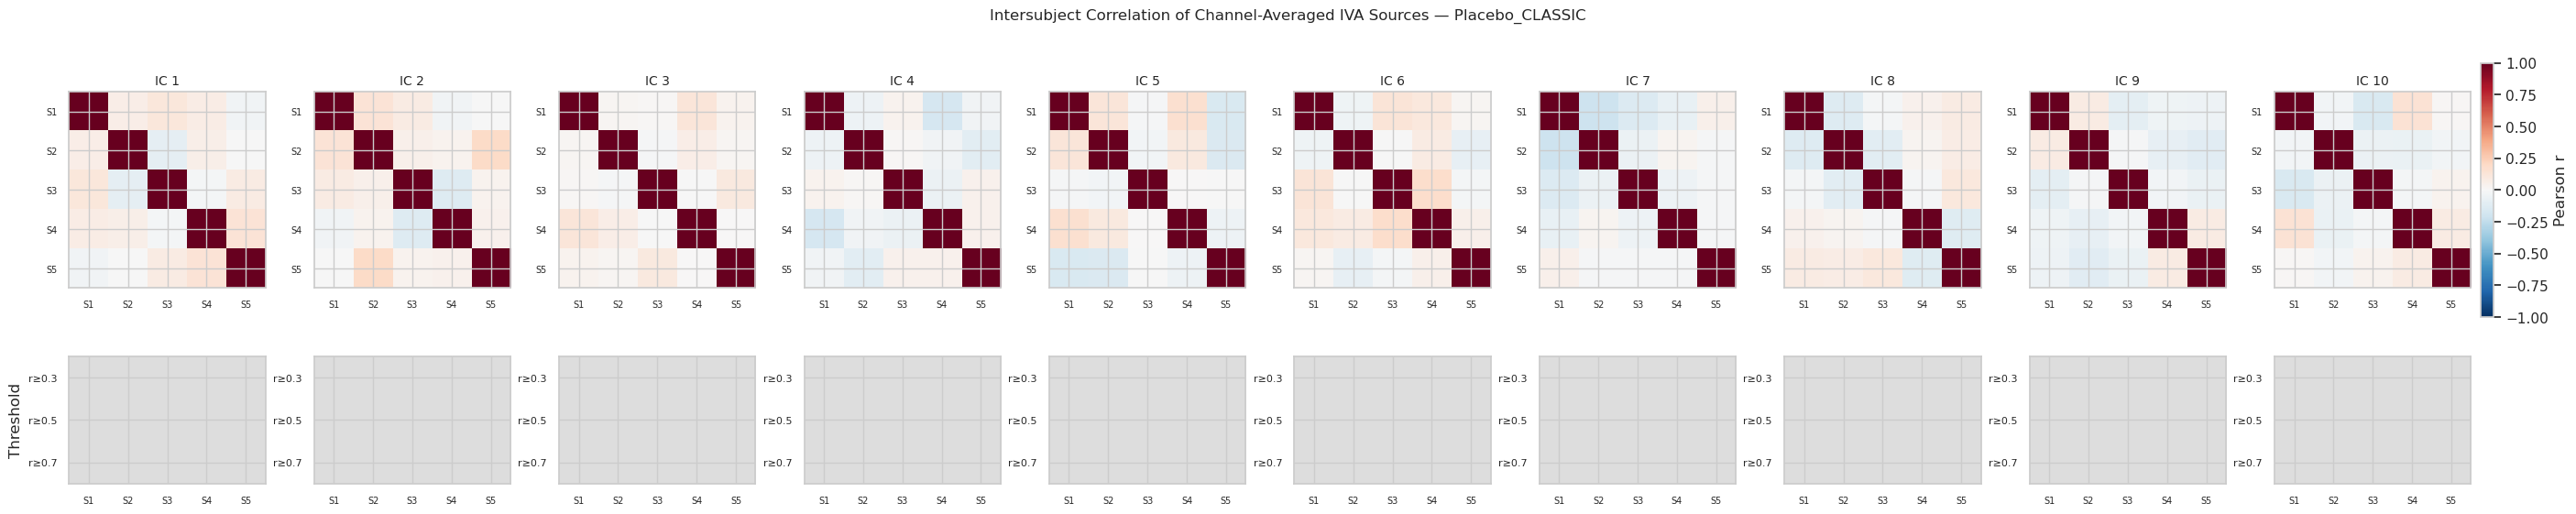

In [13]:
# Pearson-r thresholds used for the cluster strip below each ISC matrix.
ISC_CLUSTER_THRESHOLDS = (0.3, 0.5, 0.7)

# Discrete colormap: light gray for singletons (0) + tab10 for groups (1..10).
_GROUP_PALETTE = list(plt.colormaps["tab10"].colors)
_CLUSTER_CMAP = ListedColormap(["#dddddd"] + _GROUP_PALETTE)
_CLUSTER_NORM = BoundaryNorm(
    np.arange(-0.5, len(_GROUP_PALETTE) + 1.5, 1.0), _CLUSTER_CMAP.N
)


def _cluster_grid(
    corr_mat: np.ndarray, thresholds=ISC_CLUSTER_THRESHOLDS
) -> np.ndarray:
    """(T, S) grid of within-row cluster IDs. Singletons → 0, groups → 1, 2, ...."""
    grid = np.zeros((len(thresholds), n_subjects), dtype=int)
    for t_idx, thr in enumerate(thresholds):
        adj = (corr_mat >= thr) & ~np.eye(n_subjects, dtype=bool)
        _, labels = connected_components(adj, directed=False)
        counts = Counter(labels.tolist())
        next_group = 1
        group_map: dict[int, int] = {}
        for s in range(n_subjects):
            lab = int(labels[s])
            if counts[lab] == 1:
                grid[t_idx, s] = 0
            else:
                if lab not in group_map:
                    group_map[lab] = next_group
                    next_group += 1
                grid[t_idx, s] = group_map[lab]
    return grid


def _plot_isc_grid(corr_per_comp, fig_title, file_name):
    """Plot ISC correlation matrices + cluster strips for the first N components."""
    n_show = N_COMPONENTS_SHOW
    fig, axes = plt.subplots(
        2,
        n_show,
        figsize=(2.8 * n_show, 5.5),
        gridspec_kw={"height_ratios": [3, 1.2]},
        constrained_layout=True,
    )
    if n_show == 1:
        axes = axes.reshape(2, 1)

    im_corr = None
    for i in range(n_show):
        corr_mat = corr_per_comp[i]
        ax_top = axes[0, i]
        im_corr = ax_top.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r")
        ax_top.set_xticks(range(n_subjects))
        ax_top.set_yticks(range(n_subjects))
        ax_top.set_xticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_top.set_yticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_top.set_title(f"IC {i + 1}", fontsize=10)

        ax_bot = axes[1, i]
        grid = _cluster_grid(corr_mat)
        ax_bot.imshow(grid, cmap=_CLUSTER_CMAP, norm=_CLUSTER_NORM, aspect="auto")
        for ti in range(grid.shape[0]):
            for sj in range(grid.shape[1]):
                val = int(grid[ti, sj])
                if val > 0:
                    ax_bot.text(
                        sj,
                        ti,
                        str(val),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="white",
                        weight="bold",
                    )
        ax_bot.set_xticks(range(n_subjects))
        ax_bot.set_xticklabels([f"S{s + 1}" for s in range(n_subjects)], fontsize=7)
        ax_bot.set_yticks(range(len(ISC_CLUSTER_THRESHOLDS)))
        ax_bot.set_yticklabels(
            [f"r≥{thr}" for thr in ISC_CLUSTER_THRESHOLDS], fontsize=8
        )
        if i == 0:
            ax_bot.set_ylabel("Threshold")

    fig.suptitle(fig_title, fontsize=12)
    fig.colorbar(im_corr, ax=axes[0, -1], label="Pearson r", shrink=0.8)
    if SAVE_PLOTS:
        fig.savefig(PLOTS_DIR / file_name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")


# Channel-averaged per-subject source timecourse: (S, N_IVA, T)
per_subject_source = iva_sources.mean(axis=1)

source_corr_per_comp = np.stack(
    [np.corrcoef(per_subject_source[:, k, :]) for k in range(N_COMPONENTS_SHOW)]
)

_plot_isc_grid(
    source_corr_per_comp,
    fig_title=(
        f"Intersubject Correlation of Channel-Averaged IVA Sources — {LABEL}"
    ),
    file_name="iva_source_isc_matrix.png",
)

---
## Analysis (c) — Intersubject Correlation of Channel-Averaged Component Patterns

For each component `k` the per-subject frequency pattern is the
channel-average of `iva_components[s, :, k, :]` → `(F,)`. Subject ×
subject correlations then quantify whether the kth frequency
fingerprint is shared across individuals (complementary to the source
alignment IVA enforces by construction).

| Quantity | Shape | Description |
|----------|-------|-------------|
| `per_subject_pattern` | `(S, N_IVA, F)` | Channel-averaged frequency pattern per subject |
| `pattern_corr_per_comp` | `(N_SHOW, S, S)` | Per-IC subject × subject pattern correlation |

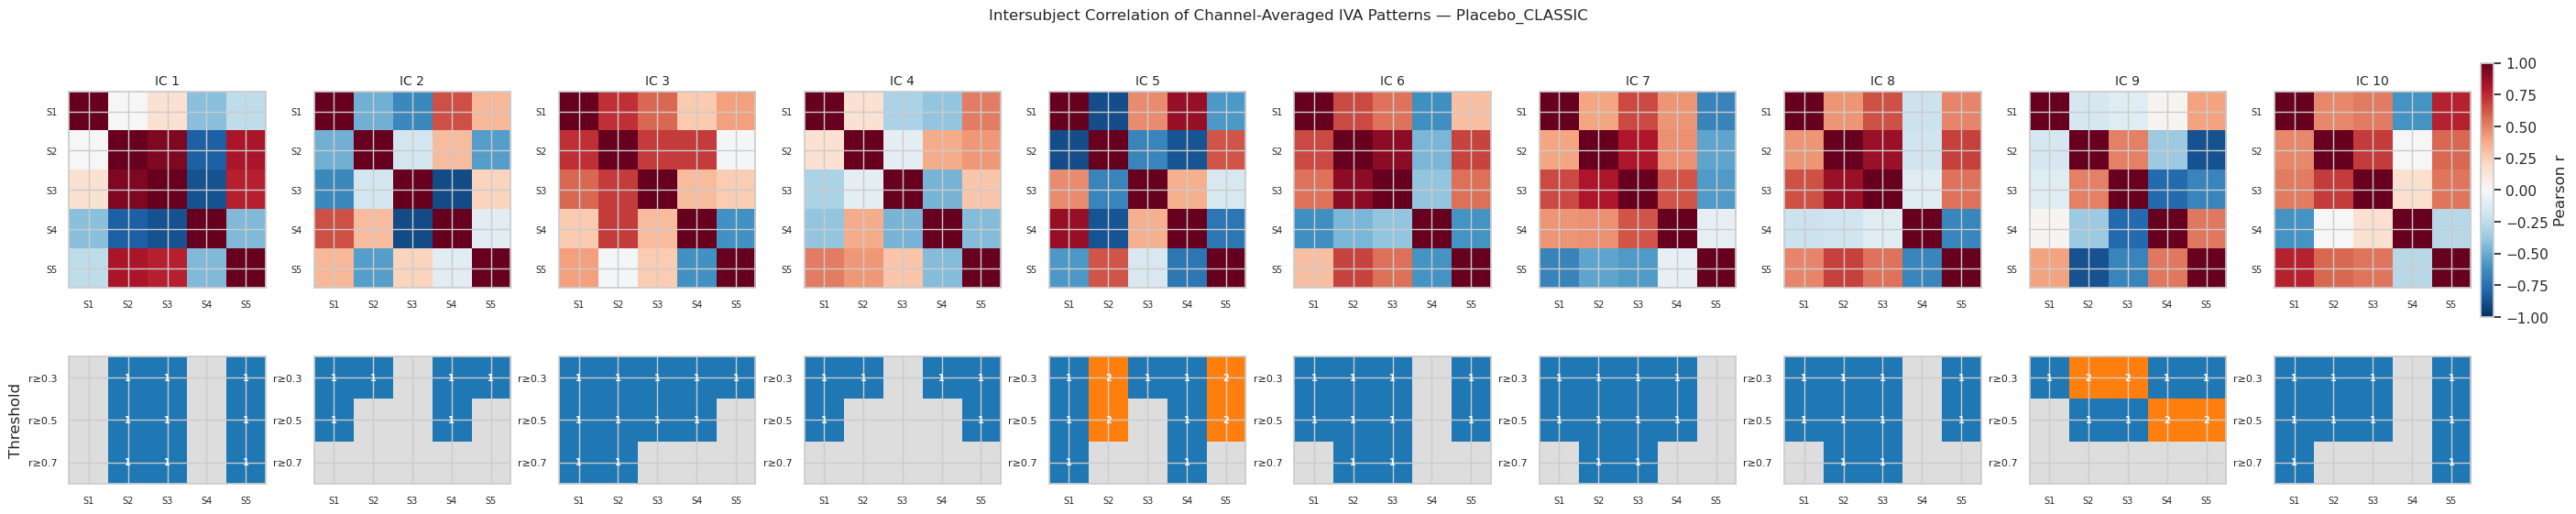

In [14]:
# Channel-averaged per-subject frequency pattern: (S, N_IVA, F)
per_subject_pattern = iva_components.mean(axis=1)

pattern_corr_per_comp = np.zeros((N_COMPONENTS_SHOW, n_subjects, n_subjects))
for k in range(N_COMPONENTS_SHOW):
    pattern_corr_per_comp[k] = np.corrcoef(per_subject_pattern[:, k, :])

_plot_isc_grid(
    pattern_corr_per_comp,
    fig_title=(
        f"Intersubject Correlation of Channel-Averaged IVA Patterns — {LABEL}"
    ),
    file_name="iva_pattern_isc_matrix.png",
)

---
## Analysis (d) — Mean LOO-ISC Across Subjects per Component

Whole-recording LOO-ISC using the **channel-averaged** per-subject
source timecourses from (b).

```
for each subject s:
    others_mean = mean over s' ≠ s of per_subject_source[s', k, :]
    r[k, s]     = pearson(per_subject_source[s, k, :], others_mean)
```

| Quantity | Shape | Description |
|----------|-------|-------------|
| `loo_isc_per_subject` | `(N_SHOW, S)` | Whole-recording LOO-ISC per IC and subject |
| `loo_isc_mean` | `(N_SHOW,)` | Across-subject mean LOO-ISC per IC |
| `loo_isc_std` | `(N_SHOW,)` | Across-subject std LOO-ISC per IC |

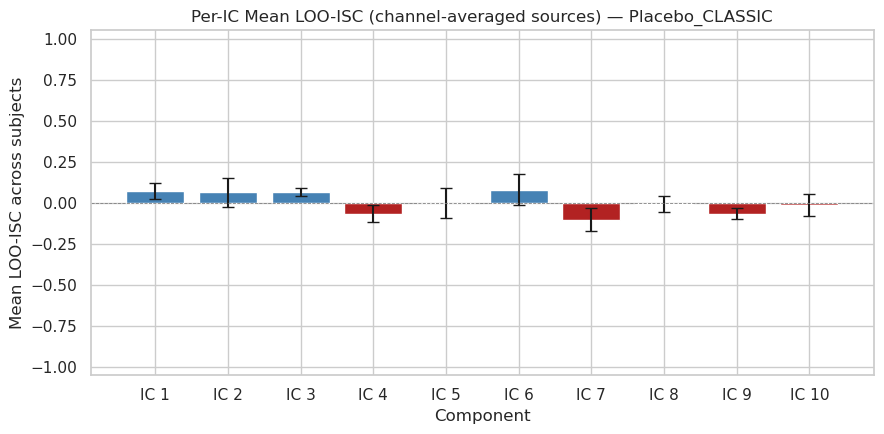

In [15]:
# Channel-averaged per-subject source timecourses (defined in cell d61570eb).
loo_isc_per_subject = np.zeros((N_COMPONENTS_SHOW, n_subjects))
for k in range(N_COMPONENTS_SHOW):
    subj_vectors = per_subject_source[:, k, :]  # (S, T)
    for s in range(n_subjects):
        others_mean = np.delete(subj_vectors, s, axis=0).mean(axis=0)
        loo_isc_per_subject[k, s] = float(pearsonr(subj_vectors[s], others_mean)[0])

loo_isc_mean = loo_isc_per_subject.mean(axis=1)
loo_isc_std = loo_isc_per_subject.std(axis=1)

bar_colors = ["firebrick" if m < 0 else "steelblue" for m in loo_isc_mean]

fig, ax = plt.subplots(figsize=(max(8, 0.9 * N_COMPONENTS_SHOW), 4.5))
xs = np.arange(N_COMPONENTS_SHOW)
ax.bar(xs, loo_isc_mean, yerr=loo_isc_std, color=bar_colors, capsize=4)
ax.axhline(0.0, ls="--", lw=0.6, color="gray")
ax.set_xticks(xs)
ax.set_xticklabels([f"IC {k + 1}" for k in range(N_COMPONENTS_SHOW)])
ax.set_xlabel("Component")
ax.set_ylabel("Mean LOO-ISC across subjects")
ax.set_ylim(-1.05, 1.05)
ax.set_title(f"Per-IC Mean LOO-ISC (channel-averaged sources) — {LABEL}")

fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_loo_isc_bar.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (e) — Topomap of Mean and Variance Across Subjects

Each `(s, c)` dataset has its own component pattern in `F` space —
the natural **channel loading** for component `k` is the per-`(s, c)`
mean of `iva_components[s, c, k, :]`. Stacking gives `(S, C, N_IVA)`;
we then take the mean and variance across subjects per channel to get
two topomaps per component.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `chan_loading` | `(S, C, N_IVA)` | Mean-over-frequency loading per `(s, c)` |
| `chan_mean` | `(N_IVA, C)` | Across-subject mean channel loading |
| `chan_var` | `(N_IVA, C)` | Across-subject variance channel loading |

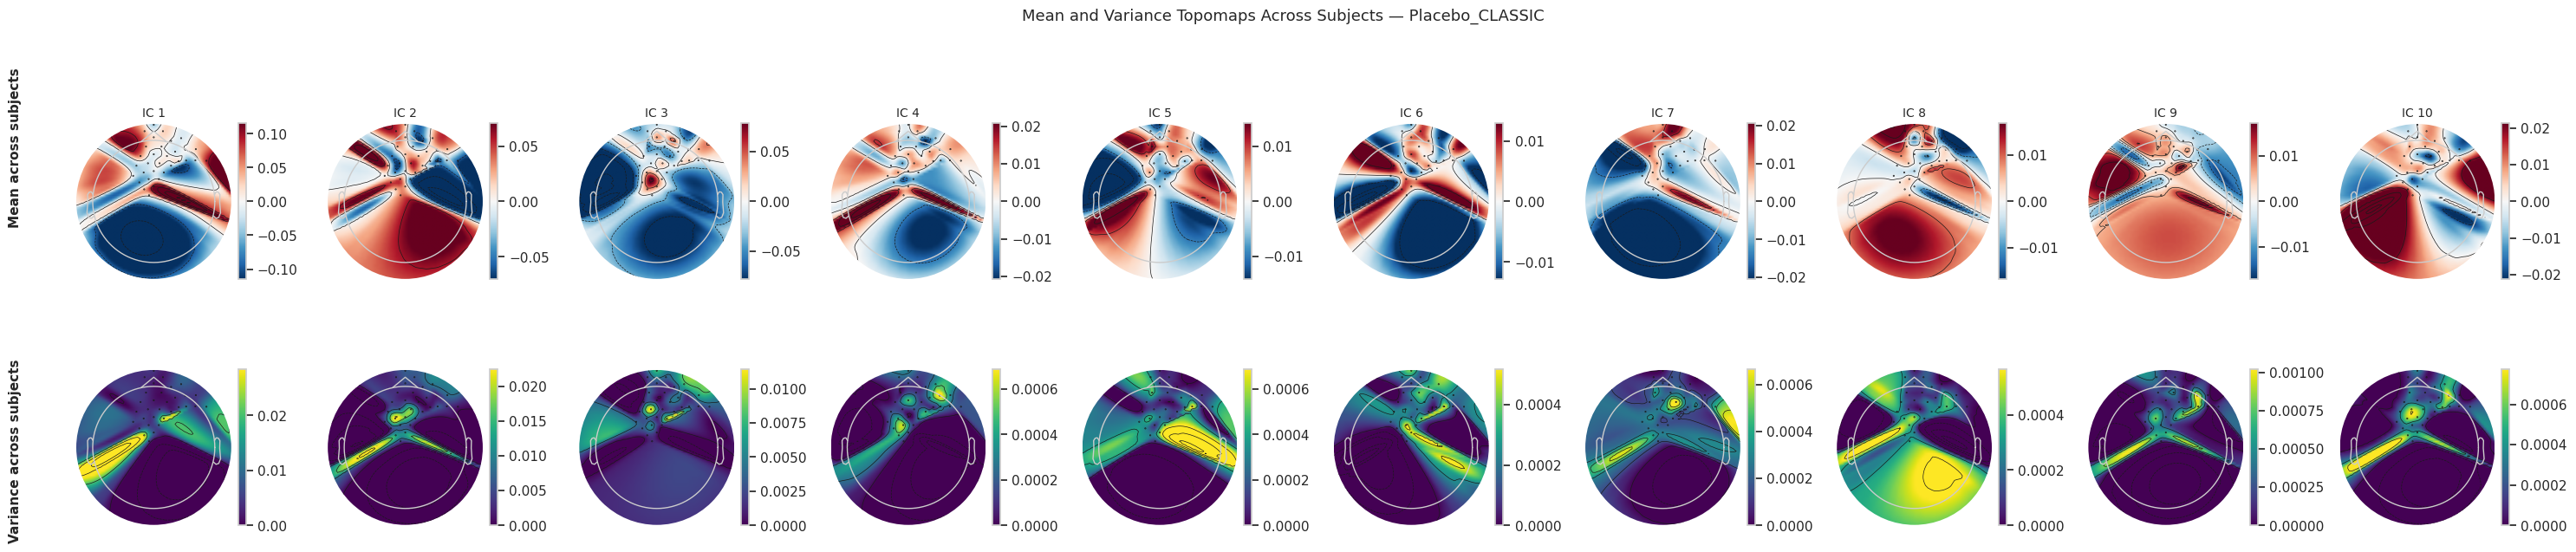

In [16]:
# Per-(s, c) channel loading (collapse frequency axis): (S, C, N_IVA)
chan_loading = iva_components.mean(axis=-1)
# Mean / variance across subjects per channel: (N_IVA, C)
chan_mean = chan_loading.mean(axis=0).T
chan_var = chan_loading.var(axis=0).T

# MNE info for the topomap, restricted to the channel subset.
info = analyzers[LABEL].info
info = mne.pick_info(info, mne.pick_types(info, eeg=True))
if n_channels < len(info.ch_names):
    info = mne.pick_info(info, list(range(n_channels)))

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(2, n_show, figsize=(3.0 * n_show, 7.0))
if n_show == 1:
    axes = axes.reshape(2, 1)

for i in range(n_show):
    vlim_m = float(np.percentile(np.abs(chan_mean[i]), 99))
    if vlim_m == 0.0:
        vlim_m = 1e-12
    im_m, _ = plot_topomap(
        chan_mean[i],
        info,
        axes=axes[0, i],
        show=False,
        cmap="RdBu_r",
        vlim=(-vlim_m, vlim_m),
    )
    axes[0, i].set_title(f"IC {i + 1}", fontsize=10)
    fig.colorbar(im_m, ax=axes[0, i], fraction=0.046, pad=0.04)

    vlim_v = float(np.percentile(chan_var[i], 99))
    if vlim_v == 0.0:
        vlim_v = 1e-12
    im_v, _ = plot_topomap(
        chan_var[i],
        info,
        axes=axes[1, i],
        show=False,
        cmap="viridis",
        vlim=(0.0, vlim_v),
    )
    fig.colorbar(im_v, ax=axes[1, i], fraction=0.046, pad=0.04)

fig.text(
    0.01,
    0.75,
    "Mean across subjects",
    rotation=90,
    va="center",
    fontsize=11,
    fontweight="bold",
)
fig.text(
    0.01,
    0.25,
    "Variance across subjects",
    rotation=90,
    va="center",
    fontsize=11,
    fontweight="bold",
)
fig.suptitle(
    f"Mean and Variance Topomaps Across Subjects — {LABEL}",
    fontsize=13,
)
fig.tight_layout(rect=(0.03, 0, 1, 0.97))
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_topomap_mean_var.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (f) — Time × Frequency Map per Component (Outer Product)

Same outer-product construction as the subjects notebook, but with
the `(S, C)` averaging applied first to both the frequency pattern
and the source timecourse:

```
freq_profile[k] = iva_components.mean(axis=(0, 1))[k]       # (F,)
time_profile[k] = iva_sources.mean(axis=(0, 1))[k]          # (T,)
tf_map[k]       = outer(freq_profile[k], time_profile[k])   # (F, T)
```

| Quantity | Shape | Description |
|----------|-------|-------------|
| `freq_profiles` | `(F, N_IVA)` | Mean-over-`(S, C)` frequency profile per IC |
| `time_profiles` | `(N_IVA, T)` | Mean-over-`(S, C)` source timecourse per IC |
| `ft_maps` | `(N_IVA, F, T)` | Outer-product frequency × time map per component |

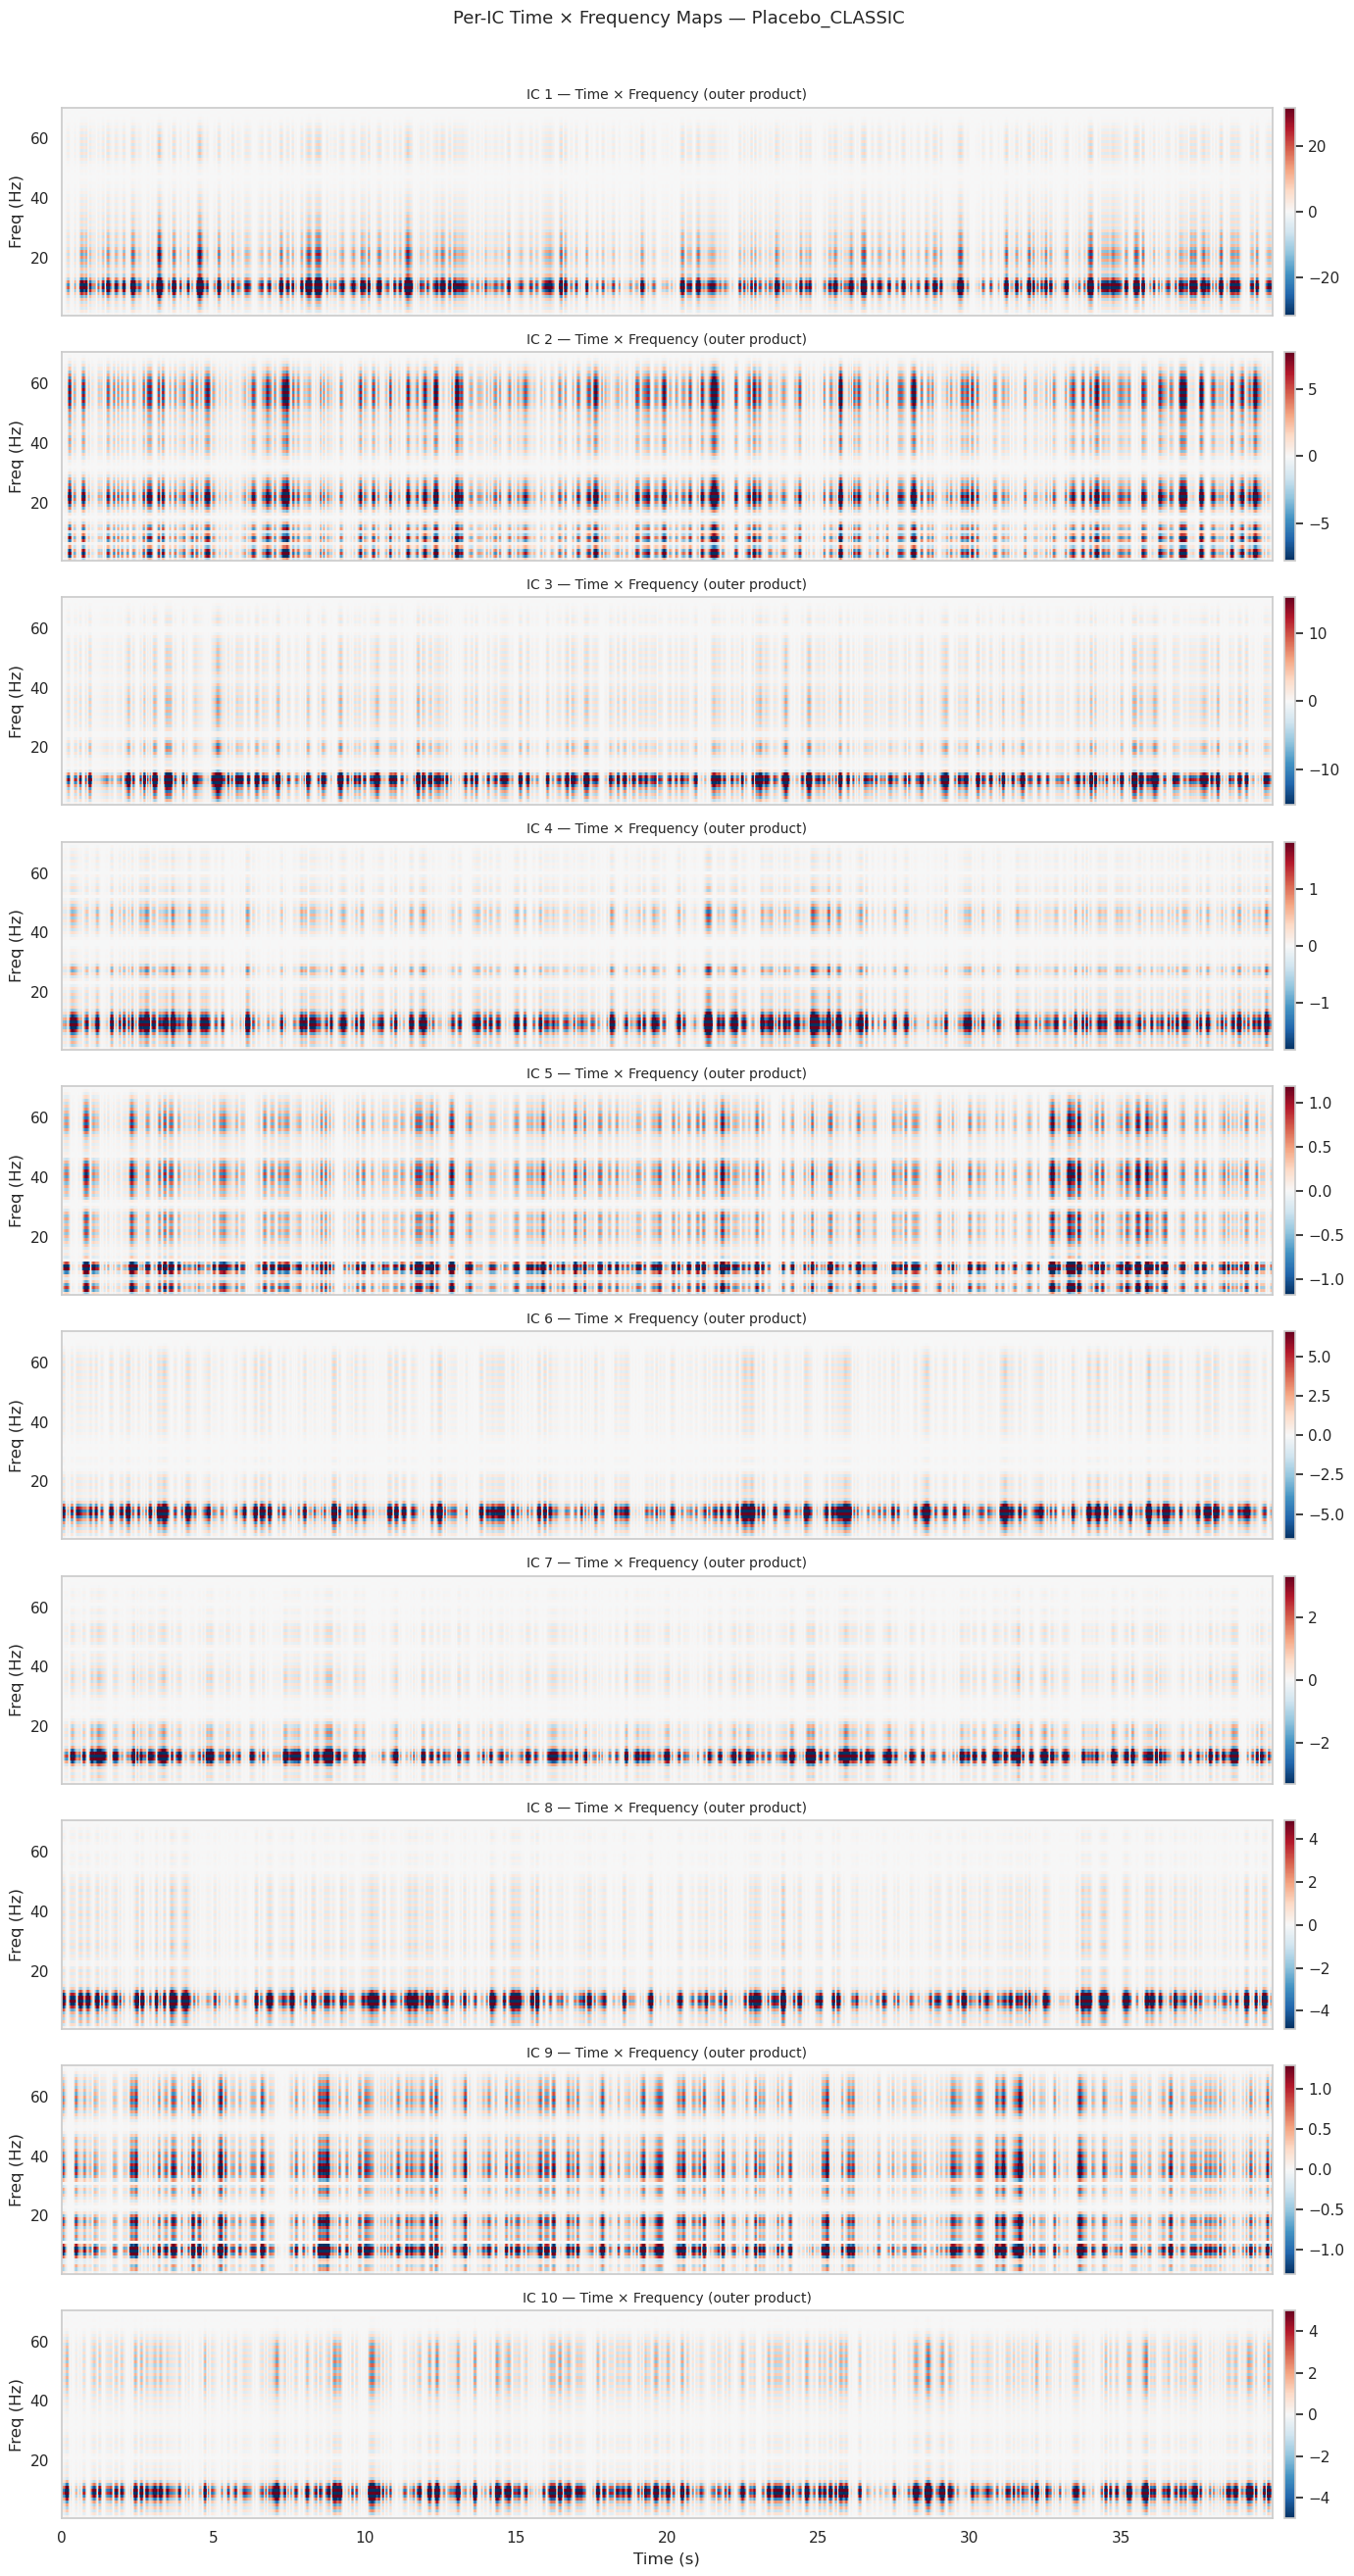

In [17]:
# Subject- and channel-averaged frequency pattern: (N_IVA, F) → (F, N_IVA)
mean_components = iva_components.mean(axis=(0, 1))
freq_profiles = mean_components.T  # (F, N_IVA)

# Subject- and channel-averaged source timecourse: (N_IVA, T)
time_profiles = iva_sources.mean(axis=(0, 1))

# Outer product per component → (N_IVA, F, T)
ft_maps = np.einsum("fk,kt->kft", freq_profiles, time_profiles)

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.6 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    data_i = ft_maps[i]
    vlim_i = np.percentile(np.abs(data_i), 99)
    mesh = ax.pcolormesh(
        time,
        FREQS,
        data_i,
        cmap="RdBu_r",
        vmin=-vlim_i,
        vmax=vlim_i,
        shading="auto",
    )
    ax.set_ylabel("Freq (Hz)")
    ax.set_title(f"IC {i + 1} — Time × Frequency (outer product)", fontsize=10)
    fig.colorbar(mesh, ax=ax, pad=0.01, fraction=0.025)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"Per-IC Time × Frequency Maps — {LABEL}", fontsize=13, y=1.01)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / "iva_time_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

---
## Analysis (g) — Source Timecourses: Mean and Variance Across `(S × C)` Datasets

For each component `k` the timecourse is summarised at every time
point over **all `S × C` datasets**:

```
mean_temporal[k, t] = mean over (s, c) of iva_sources[s, c, k, t]
var_temporal[k, t]  = var  over (s, c) of iva_sources[s, c, k, t]
std_temporal[k, t]  = sqrt(var_temporal[k, t])
```

The error band is `mean ± √variance`. Narrow bands indicate that the
kth source's temporal expression is consistent across **both**
subjects and channels — a stronger consistency criterion than the
subjects-only band in `wavelet_iva_subjects.ipynb`.

| Quantity | Shape | Description |
|----------|-------|-------------|
| `mean_temporal` | `(N_IVA, T)` | Mean source across `(s, c)` |
| `var_temporal` | `(N_IVA, T)` | Variance of source across `(s, c)` |
| `std_temporal` | `(N_IVA, T)` | Std (band width) |

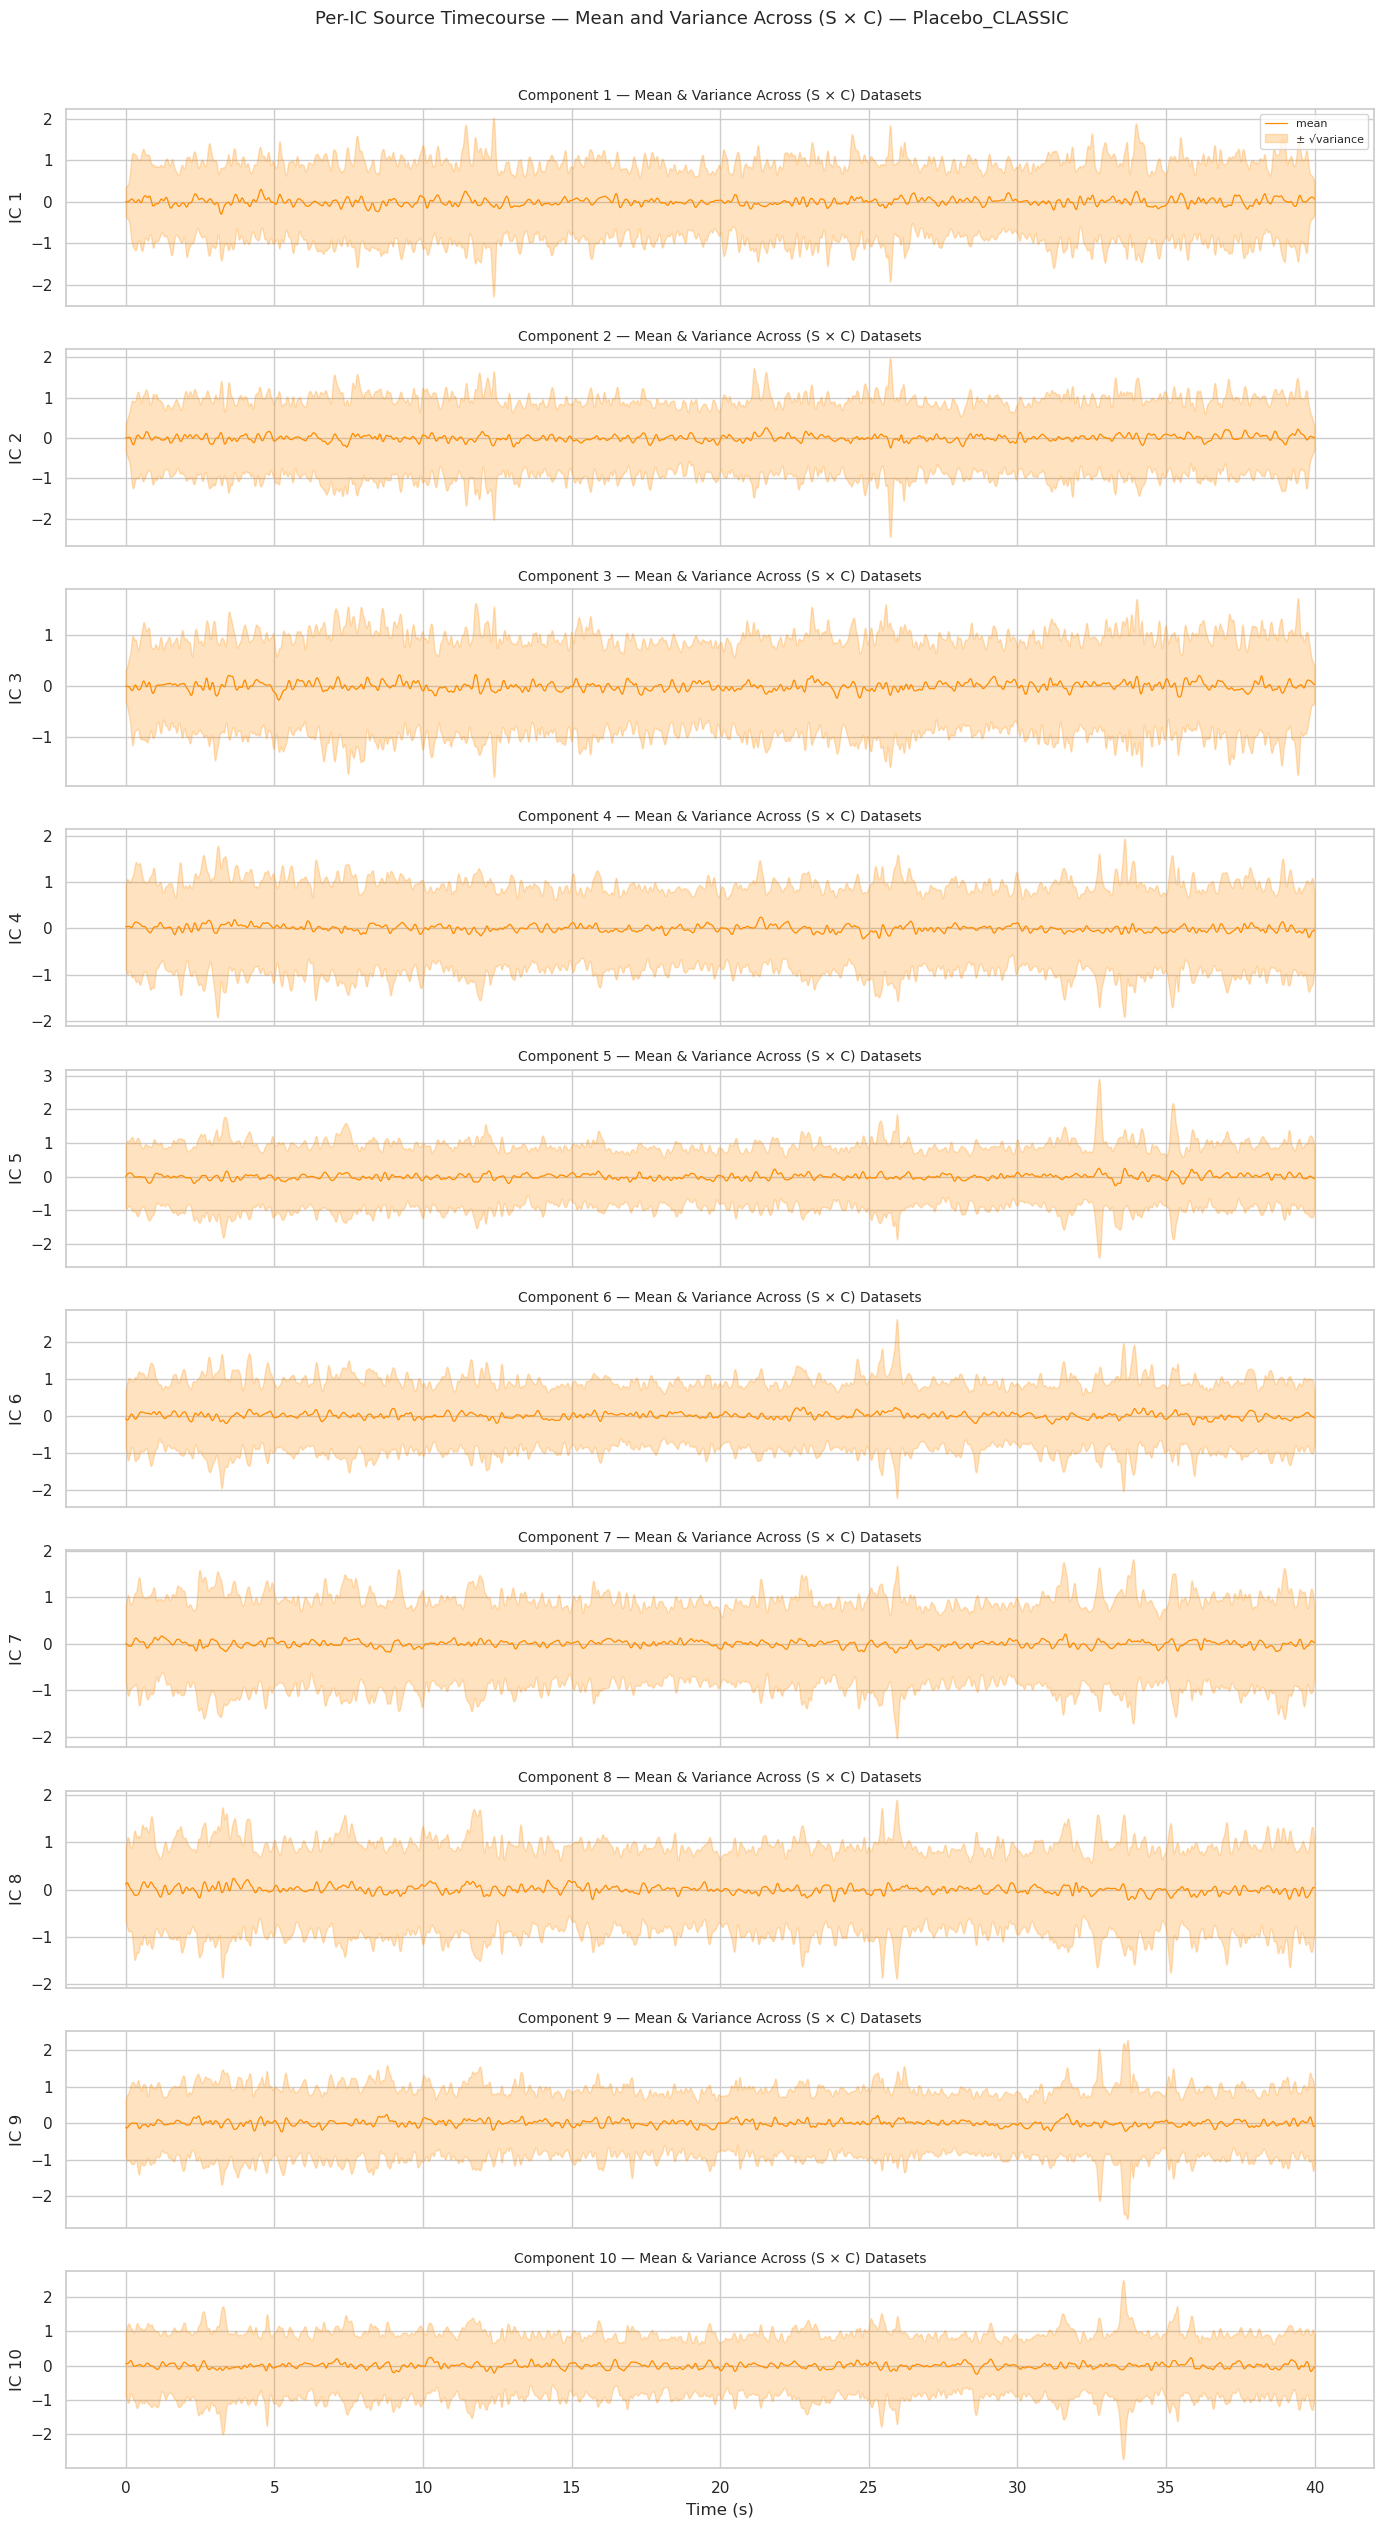

In [18]:
# Stack S and C into a single dataset axis so the across-dataset summary
# treats each (subject, channel) as one observation.
sources_flat = iva_sources.reshape(n_subjects * n_channels, N_IVA, n_times)
mean_temporal = sources_flat.mean(axis=0)
var_temporal = sources_flat.var(axis=0)
std_temporal = np.sqrt(var_temporal)

n_show = N_COMPONENTS_SHOW
fig, axes = plt.subplots(n_show, 1, figsize=(14, 2.5 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.plot(time, mean_temporal[i], lw=0.9, color="darkorange", label="mean")
    ax.fill_between(
        time,
        mean_temporal[i] - std_temporal[i],
        mean_temporal[i] + std_temporal[i],
        alpha=0.25,
        color="darkorange",
        label="± √variance",
    )
    ax.set_ylabel(f"IC {i + 1}")
    ax.set_title(
        f"Component {i + 1} — Mean & Variance Across (S × C) Datasets",
        fontsize=10,
    )
    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"Per-IC Source Timecourse — Mean and Variance Across (S × C) — {LABEL}",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(
        PLOTS_DIR / "iva_mean_variance_over_time.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()
plt.close("all")